In [2]:
import numpy as np
x = np.zeros((10, 1))
x

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [3]:
x.flatten()

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [5]:
stimulating_electrode_position = np.array([0, 0, 250])
stimulating_electrode_position

array([  0,   0, 250])

In [11]:
y = [1,2,3]
stimulating_electrode_position = np.array([0, 0, 250])
z = stimulating_electrode_position-y
print(y)

[1, 2, 3]


In [12]:
dot_product = np.dot(z,z)
print(dot_product)

61014


In [17]:
nseg = 10
test = np.arange(0, nseg + 2)* (1 / nseg) 
print(test)

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1]


In [23]:
L = 100

segment_centres = np.arange(0, nseg + 3 - 1) * (1 / nseg)
segment_centres = segment_centres - (1 / (2 * nseg))
segment_centres[0] = 0
segment_centres[-1] = 1
segment_centres = segment_centres[1 : len(segment_centres) - 1]
z_coordinate = L * segment_centres - L / 2

print(segment_centres)

print(z_coordinate)

[0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95]
[-45. -35. -25. -15.  -5.   5.  15.  25.  35.  45.]


In [24]:
import matplotlib.pyplot as plt
import numpy as np

def plot_collateral_distances(distances, n_cells=20):
    """
    Plot a heatmap of collateral segment distances from electrode.

    Parameters:
    - distances: 2D numpy array (cells x segments)
    - n_cells: how many cells to plot (default 20)
    """

    # Limit the number of cells to plot for readability
    data_to_plot = distances[:n_cells, :]

    plt.figure(figsize=(10, 6))
    plt.imshow(data_to_plot, aspect='auto', cmap='viridis')
    plt.colorbar(label='Distance from electrode (µm)')
    plt.xlabel('Collateral Segment Index')
    plt.ylabel('Cortical Cell Index')
    plt.title(f'Distances of collateral segments to stimulating electrode\n(Showing first {n_cells} cells)')
    plt.show()

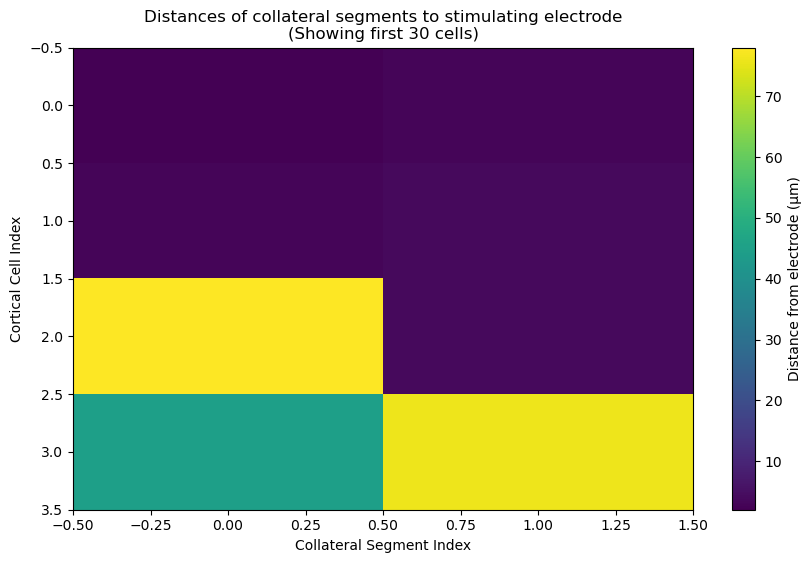

In [40]:
segment_electrode_distances = np.array([[2,3],[3,4],[78,4],[45,76]])
plot_collateral_distances(segment_electrode_distances, n_cells=30)

In [39]:
x =  np.array([[2,3],[3,4],[78,4],[45,76]])
print(x)

[[ 2  3]
 [ 3  4]
 [78  4]
 [45 76]]


In [7]:
import numpy as np
array = np.array([[2,3,4],[3,4,5],[6,7,8]])
print(array)


[[2 3 4]
 [3 4 5]
 [6 7 8]]


In [8]:
print(array[1])

[3 4 5]


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # for 3D plotting

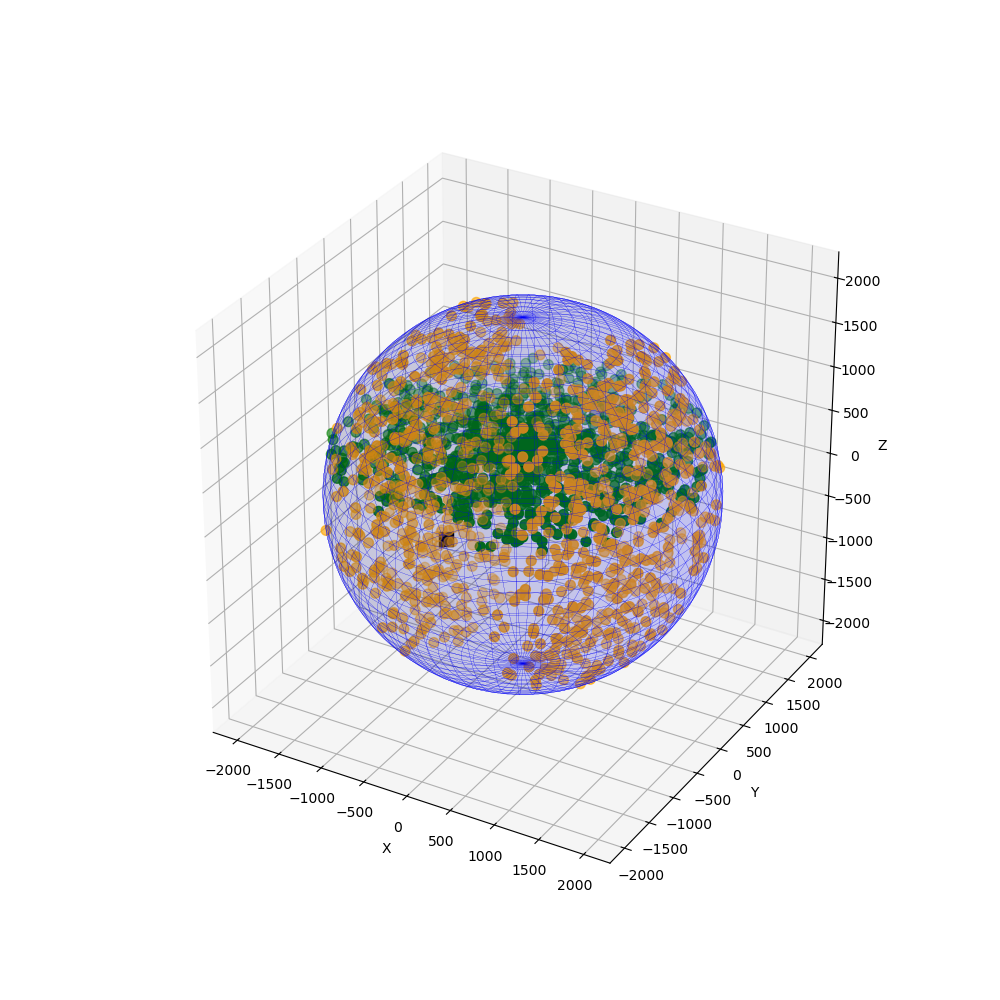

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
%matplotlib widget

#plot sphere of STN
theta = np.linspace(0, 2 * np.pi, 100)
phi = np.linspace(0, np.pi, 50)
theta, phi = np.meshgrid(theta, phi)
r = 2000

# Convert to Cartesian coordinates
x = r * np.sin(phi) * np.cos(theta)
y = r * np.sin(phi) * np.sin(theta)
z = r * np.cos(phi)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, color = "blue", edgecolor = "blue",linewidth = 0.1,alpha=0.1)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_box_aspect((1, 1, 1))

#plot the stimulating electrode
ax.scatter(0, 0, 250, c='black', s=100, marker = "s")
#plot the receiving electrode
ax.scatter([0,0], [-1500,1500], [250,250], c='black', s=100, marker = "s")

## add in the STN neurons
num_points = 1000
x_points_clean = []
y_points_clean = []
z_points = np.repeat(500, num_points)

while len(x_points_clean) < num_points:
    # Generate a random point inside a sphere (uniformly)
    theta = np.random.uniform(0, 2 * np.pi)
    phi = np.random.uniform(0, np.pi)
    r_1 = r * np.random.uniform(0, 1) ** (1/3)

    # Convert spherical to Cartesian coordinates
    x = r_1 * np.sin(phi) * np.cos(theta)
    y = r_1 * np.sin(phi) * np.sin(theta)
    z = r_1 * np.cos(phi)

    # Apply constraints
    if abs(x) > 500 or y > -1500:
        x_points_clean.append(x)
        y_points_clean.append(y)

ax.scatter(x_points_clean, y_points_clean, z_points, c='green', s=50)

##### add in the cortical neurons
num_points = 1000
x_points_clean_ctx = []
y_points_clean_ctx = []
z_points_clean_ctx = []

while len(x_points_clean_ctx) < num_points:
    # Generate a random point inside a sphere (uniformly)
    theta = np.random.uniform(0, 2 * np.pi)
    phi = np.random.uniform(0, np.pi)
    r_1 = r * np.random.uniform(0, 1) ** (1/3)

    # Convert spherical to Cartesian coordinates
    x = r_1 * np.sin(phi) * np.cos(theta)
    y = r_1 * np.sin(phi) * np.sin(theta)
    z = r_1 * np.cos(phi)

    # Apply constraints
    if abs(x) > 500 and y > -1500:
        x_points_clean_ctx.append(x)
        y_points_clean_ctx.append(y)
        z_points_clean_ctx.append(z)

ax.scatter(x_points_clean_ctx, y_points_clean_ctx, z_points_clean_ctx, c='orange', s=50)

plt.show()

In [ ]:

'''#add the zone where there are no neurons
# Define cube vertices
cube_vertices = np.array([
    [0, 0, 0],  # point 0
    [1, 0, 0],  # point 1
    [1, 1, 0],  # point 2
    [0, 1, 0],  # point 3
    [0, 0, 1],  # point 4
    [1, 0, 1],  # point 5
    [1, 1, 1],  # point 6
    [0, 1, 1]   # point 7
])

# Define cube faces using the vertices
# Define cube vertices
cube_vertices = np.array([
    [-500, -1500, -2000],  # point 0
    [500, -1500, -2000],  # point 1
    [500, 1500, -2000],  # point 2
    [-500, 1500, -2000],  # point 3
    [-500, -1500, 2000],  # point 0
    [500, -1500, 2000],  # point 1
    [500, 1500, 2000],  # point 2
    [-500, 1500, 2000],  # po
])

# Define cube faces using the vertices
faces = [
    [cube_vertices[i] for i in [0, 1, 2, 3]],  # bottom
    [cube_vertices[i] for i in [4, 5, 6, 7]],  # top
    [cube_vertices[i] for i in [0, 1, 5, 4]],  # front
    [cube_vertices[i] for i in [2, 3, 7, 6]],  # back
    [cube_vertices[i] for i in [1, 2, 6, 5]],  # right
    [cube_vertices[i] for i in [0, 3, 7, 4]]   # left
]

ax.add_collection3d(Poly3DCollection(faces, facecolors='red',linewidths=1, edgecolor = "red",alpha=0.2))''

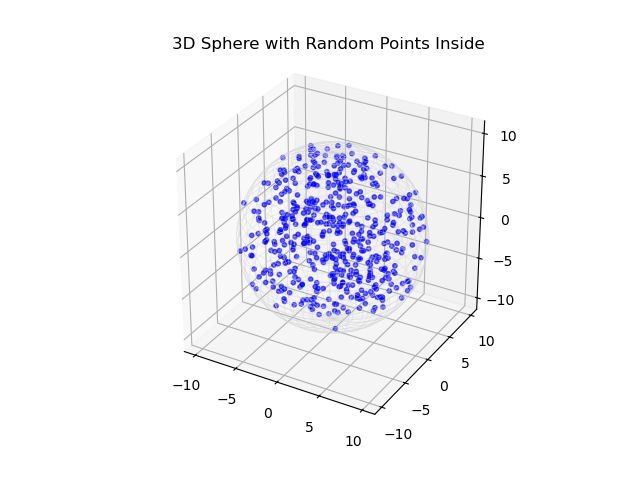

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Sphere settings ---
radius = 10
num_points = 500

# --- Generate random points inside the sphere ---
# Using spherical coordinates with uniform distribution inside a sphere
u = np.random.uniform(0, 1, num_points)
theta = np.random.uniform(0, 2 * np.pi, num_points)
phi = np.arccos(np.random.uniform(-1, 1, num_points))
r = radius * (u ** (1/3))  # cube root ensures uniform volume distribution

# Convert to Cartesian coordinates
x = r * np.sin(phi) * np.cos(theta)
y = r * np.sin(phi) * np.sin(theta)
z = r * np.cos(phi)

# --- Create a sphere surface for reference (wireframe) ---
u_sphere = np.linspace(0, 2 * np.pi, 30)
v_sphere = np.linspace(0, np.pi, 30)
x_sphere = radius * np.outer(np.cos(u_sphere), np.sin(v_sphere))
y_sphere = radius * np.outer(np.sin(u_sphere), np.sin(v_sphere))
z_sphere = radius * np.outer(np.ones_like(u_sphere), np.cos(v_sphere))

# --- Plotting ---
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Draw sphere wireframe
ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color='lightgray', linewidth=0.5, alpha=0.5)

# Plot points inside sphere
ax.scatter(x, y, z, color='blue', s=10, alpha=0.6)

# Set equal aspect ratio
ax.set_box_aspect([1,1,1])
ax.set_title("3D Sphere with Random Points Inside")

plt.show()

In [80]:
import numpy as np
r = 1000  # sphere radius
num_points = 50

x_points_clean = []
y_points_clean = []
z_points_clean = []

while len(x_points_clean) < num_points:
    # Generate a random point inside the sphere
    theta = np.random.uniform(0, 2 * np.pi)
    phi = np.random.uniform(0, np.pi)
    radius = r * np.cbrt(np.random.uniform(0, 1))  # uniform volume

    x = radius * np.sin(phi) * np.cos(theta)
    y = radius * np.sin(phi) * np.sin(theta)
    z = radius * np.cos(phi)

    # Reject if abs(x) < 500
    if np.abs(x) < 500:
        continue  # try again

    # Otherwise, save the point
    x_points_clean.append(x)
    y_points_clean.append(y)
    z_points_clean.append(z)


print(x_points_clean)

[np.float64(-558.9652117017582), np.float64(-752.7056959760838), np.float64(-520.832471098086), np.float64(-538.9154224424966), np.float64(754.7241007391837), np.float64(668.6405932846958), np.float64(-502.0965668540155), np.float64(918.8722901053328), np.float64(-632.9883406580619), np.float64(-719.6490004771392), np.float64(757.0623891564851), np.float64(573.1961901699982), np.float64(802.4977664451475), np.float64(-508.2341717862808), np.float64(-557.8119956570192), np.float64(819.8076454604611), np.float64(-796.9121400186226), np.float64(-730.6314407879917), np.float64(-545.6733729528353), np.float64(629.0887504014984), np.float64(-502.9771895403636), np.float64(722.0364558089623), np.float64(-796.9042125325548), np.float64(-608.1530129555165), np.float64(-636.0825062210155), np.float64(-696.6530809946322), np.float64(785.8404574721648), np.float64(516.5456934899366), np.float64(538.852117137503), np.float64(-543.1706456517697), np.float64(-674.9003921735872), np.float64(694.734069

In [57]:
num_points = 100
r_1 = np.random.uniform(0, 2000, num_points)
theta_points = np.random.uniform(0, 2 * np.pi, num_points)
phi_points = np.random.uniform(0, np.pi, num_points)
x_points = r_1 * np.sin(phi_points) * np.cos(theta_points)
y_points = r_1 * np.sin(phi_points) * np.sin(theta_points)

print(x_points, y_points)

[ 6.01258681e+02  4.17347293e+02  2.49928627e+02  9.78426789e+02
 -1.49438134e+03 -1.30279131e+02  2.70882058e+02  7.72720230e+01
  6.96059092e+02 -4.43113093e+02 -5.09720841e-01  3.34730767e+02
 -1.80906318e+03  4.59731610e-01 -1.63696822e+01 -1.77732678e+03
  5.20539786e+02 -2.62782036e+02 -2.20976208e+02 -5.35605594e+01
  3.46027953e+01  3.14075163e+02 -1.10228221e+03 -6.18306875e+02
 -1.04970577e+03  5.96905282e+02 -4.38309834e+00  1.79125104e+03
  9.49377299e+01  8.41152695e+02 -2.77855697e+01 -8.91752318e+02
 -2.63281550e+02 -8.77794286e+01 -6.27174313e+02 -6.53907795e+02
  4.17749293e+02  5.35968932e+01 -1.79172590e+02  9.74993053e+02
 -1.92143405e+02 -1.36254380e+02 -2.22924118e+02 -8.28571382e+00
  2.36133016e+02  5.23776685e+02 -1.28099567e+01 -6.91445511e+02
 -5.38095338e+02  1.57465009e+02 -2.91186107e+00  5.14376722e+00
 -2.78882280e+02  8.58431424e+02  5.32322252e+01 -1.38951278e+03
  2.60842907e+02  2.29666904e+02  1.04137640e+03 -1.19009196e+03
 -5.96561437e+02 -2.00512

In [83]:
x_points[1]
    

np.float64(-814.5579248218953)

In [73]:
print(x_points)

[  534.70058623  -814.55792482  1934.53994404   591.4447985
   461.81361116 -1559.26700824   824.0917697    -22.04059741
 -1952.13164585  -796.53903354]


In [22]:
x = 1500
y = 856
x_points_clean = []
y_points_clean = []
if abs(x) >= 500 and y > -1500:
    x_points_clean.append(x)
    y_points_clean.append(y)
    print(x_points_clean, y_points_clean)
else:
    print("no")

[1500] [856]


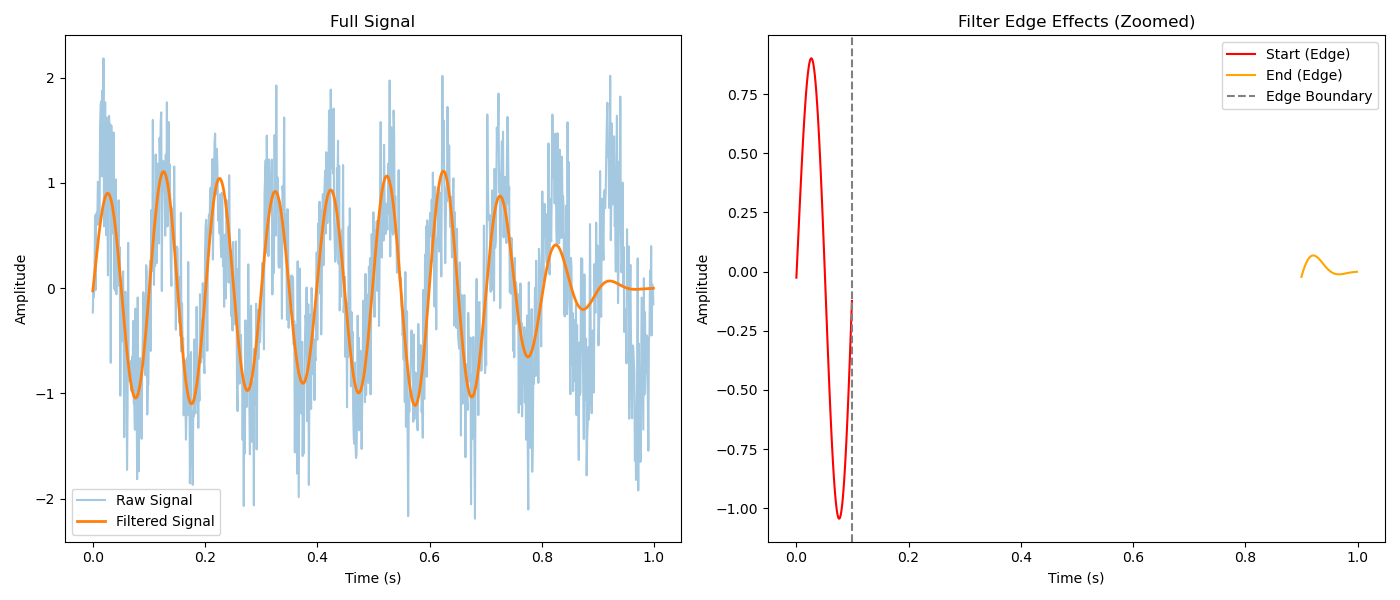

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# Create a synthetic signal: sine wave + noise
fs = 1000  # Sampling frequency (Hz)
t = np.linspace(0, 1, fs, endpoint=False)  # 1 second
signal = np.sin(2 * np.pi * 10 * t) + 0.5 * np.random.randn(fs)  # 10 Hz signal + noise

# Design a bandpass Butterworth filter (e.g., 8-12 Hz)
lowcut = 8
highcut = 12
order = 4
nyq = 0.5 * fs
b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')

# Apply filter using filtfilt (zero-phase, bidirectional)
filtered_signal = filtfilt(b, a, signal)

# Show edge effects by zooming in near the start and end
tail_len = 100  # samples to show at each edge

plt.figure(figsize=(14, 6))

# Plot the full signals
plt.subplot(1, 2, 1)
plt.plot(t, signal, label="Raw Signal", alpha=0.4)
plt.plot(t, filtered_signal, label="Filtered Signal", linewidth=2)
plt.title("Full Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()

# Zoom in on the first and last 100 samples
plt.subplot(1, 2, 2)
plt.plot(t[:tail_len], filtered_signal[:tail_len], label="Start (Edge)", color='red')
plt.plot(t[-tail_len:], filtered_signal[-tail_len:], label="End (Edge)", color='orange')
plt.axvline(x=t[tail_len-1], color='gray', linestyle='--', label="Edge Boundary")
plt.title("Filter Edge Effects (Zoomed)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()

plt.tight_layout()
plt.show()


In [5]:
def generate_monophasic_square_dbs_signal(
    start_time,
    stop_time,
    dt,
    amplitude,
    frequency,
    pulse_width,
    offset,
    last_pulse_time_prior=0,
):
    """
    Generate monophasic square-wave DBS signal

    Parameters:
        start_time (float): Stimulation start time (ms)
        stop_time (float): Stimulation stop time (ms)
        dt (float): Timestep (ms)
        amplitude (float): Stimulation amplitude (mA); <0 = cathodic, >0 = anodic
        frequency (float): Stimulation frequency (Hz)
        pulse_width (float): Width of the stimulation pulse (ms)
        offset (float): DC offset of the signal (mA)
        last_pulse_time_prior (float): Time of the last delivered pulse (ms)

    Returns:
        dbs_signal (np.array): DBS stimulation waveform
        times (np.array): sample times
        next_pulse_time (float): Time of the next stimulation pulse
        last_pulse_time (float): Time of the last stimulation pulse
    """

    times = np.round(np.arange(start_time, stop_time, dt), 2)
    tmp = np.arange(0, stop_time - start_time, dt) / 1000.0

    if frequency == 0:
        dbs_signal = np.zeros(len(tmp))
        last_pulse_time = last_pulse_time_prior
        next_pulse_time = 1e9
    else:
        # Calculate the duty cycle of the DBS signal
        isi = 1000.0 / frequency  # time is in ms
        duty_cycle = pulse_width / isi
        tt = 2.0 * np.pi * frequency * tmp
        dbs_signal = offset + 0.5 * (1.0 + signal.square(tt, duty=duty_cycle))
        dbs_signal[-1] = 0.0

        # Calculate the time for the first pulse of the next segment
        try:
            last_pulse_index = np.where(np.diff(dbs_signal) < 0)[0][-1]
            next_pulse_time = times[last_pulse_index] + isi - pulse_width

            # Track when the last pulse was
            last_pulse_time = times[last_pulse_index]

        except IndexError:
            # Catch times when signal may be flat
            last_pulse_index = len(dbs_signal) - 1
            next_pulse_time = times[last_pulse_index] + isi - pulse_width
            last_pulse_time = last_pulse_time_prior

        # Rescale amplitude
        dbs_signal *= amplitude
    
    return dbs_signal, times, next_pulse_time, last_pulse_time
    

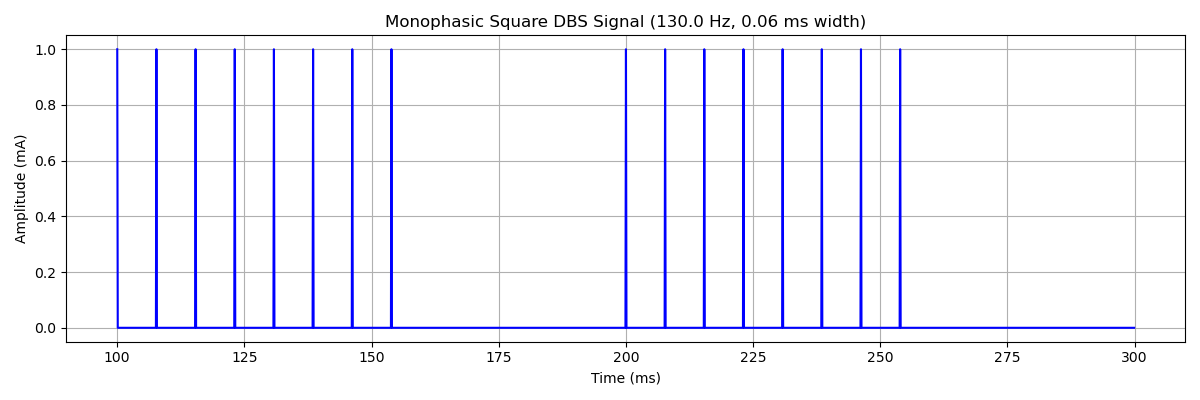

[0. 0. 1. ... 0. 0. 0.]


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal  # needed for signal.square

start_time = 100.0       # ms
stop_time = 300     # ms
dt = 0.1              # ms (sampling interval)
amplitude = 1.0         # mA (negative = cathodic)
frequency = 130.0        # Hz
pulse_width = 0.06       # ms
offset = 0.0             # mA
last_pulse_time_prior = 0.0  # ms

dbs_signal, times, next_pulse_time, last_pulse_time = generate_monophasic_square_dbs_signal(
    start_time=start_time,
    stop_time=stop_time,
    dt=dt,
    amplitude=amplitude,
    frequency=frequency,
    pulse_width=pulse_width,
    offset=offset,
    last_pulse_time_prior=last_pulse_time_prior,
)

# Plot the result
plt.figure(figsize=(12, 4))
plt.plot(times, dbs_signal, color='blue', linewidth=1.5)
plt.title(f"Monophasic Square DBS Signal ({frequency} Hz, {pulse_width} ms width)")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude (mA)")
plt.grid(True)
plt.tight_layout()
plt.show()

dbs_signal = np.hstack((np.array([0, 0]), dbs_signal))
print(dbs_signal)

[0.    0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.01  0.011
 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02  0.021 0.022 0.023
 0.024 0.025 0.026 0.027 0.028 0.029 0.03  0.031 0.032 0.033 0.034 0.035
 0.036 0.037 0.038 0.039 0.04  0.041 0.042 0.043 0.044 0.045 0.046 0.047
 0.048 0.049 0.05  0.051 0.052 0.053 0.054 0.055 0.056 0.057 0.058 0.059
 0.06  0.061 0.062 0.063 0.064 0.065 0.066 0.067 0.068 0.069 0.07  0.071
 0.072 0.073 0.074 0.075 0.076 0.077 0.078 0.079 0.08  0.081 0.082 0.083
 0.084 0.085 0.086 0.087 0.088 0.089 0.09  0.091 0.092 0.093 0.094 0.095
 0.096 0.097 0.098 0.099 0.1   0.101 0.102 0.103 0.104 0.105 0.106 0.107
 0.108 0.109 0.11  0.111 0.112 0.113 0.114 0.115 0.116 0.117 0.118 0.119
 0.12  0.121 0.122 0.123 0.124 0.125 0.126 0.127 0.128 0.129 0.13  0.131
 0.132 0.133 0.134 0.135 0.136 0.137 0.138 0.139 0.14  0.141 0.142 0.143
 0.144 0.145 0.146 0.147 0.148 0.149 0.15  0.151 0.152 0.153 0.154 0.155
 0.156 0.157 0.158 0.159 0.16  0.161 0.162 0.163 0.

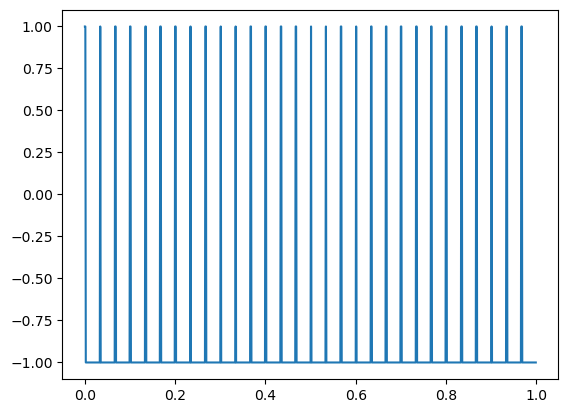

In [26]:
#sig = np.sin(2 * np.pi * t)

t = np.linspace(0, 1, 1000, endpoint=False)
pwm = signal.square(2 * np.pi * 30 * t, 0.05)
plt.plot(t, pwm)

In [25]:
start_time = 100.0       # ms
stop_time = 300     # ms
dt = 0.1              # ms (sampling interval)

print(len(np.arange(0, stop_time - start_time, dt) / 1000.0))

2000


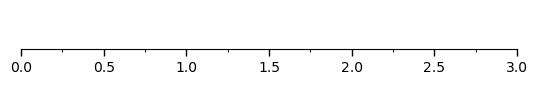

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


# Setup a plot such that only the bottom spine is shown
def setup(ax):
    ax.spines['right'].set_color('none')
    ax.spines['left'].set_color('none')
    ax.yaxis.set_major_locator(ticker.NullLocator())
    ax.spines['top'].set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.tick_params(which='major', width=1.00)
    ax.tick_params(which='major', length=5)
    ax.tick_params(which='minor', width=0.75)
    ax.tick_params(which='minor', length=2.5)
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 1)
    ax.patch.set_alpha(0.0)
#plt.figure(figsize=(8, 6))
n = 8


# Multiple Locator
ax = plt.subplot(n, 1, 2)
setup(ax)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
